Task 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("Student_performance_data _.csv")


print("Dataset Dimensions (rows, columns):")
print(df.shape)


print("\nColumn Names:")
print(df.columns.tolist())


print("\nFirst Five Rows:")
print(df.head())

Dataset Dimensions (rows, columns):
(2392, 15)

Column Names:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

First Five Rows:
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2 

In [ ]:

print("\nColumn Names:")
print(df.columns.tolist())


selected_columns = [
    "Absences",
    "StudyTimeWeekly",
    "GPA",
    "GradeClass"
]

print("\nSelected Columns:")
print(selected_columns)


Column Names:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Selected Columns:
['Absences', 'StudyTimeWeekly', 'GPA', 'GradeClass']


Task 2

In [ ]:

df["AttendanceState"] = pd.cut(
    df["Absences"],
    bins=[-1, 5, 15, 30],
    labels=["High Attendance", "Medium Attendance", "Low Attendance"]
)

df["StudyState"] = pd.cut(
    df["StudyTimeWeekly"],
    bins=[-1, 7, 14, 25],
    labels=["Low Effort", "Medium Effort", "High Effort"]
)

df["FinalState"] = pd.cut(
    df["GPA"],
    bins=[-1, 1.5, 2.5, 3.5, 4.0],
    labels=["Poor", "Average", "Good", "Excellent"]
)


df["Sequence"] = df.apply(
    lambda row: [
        row["AttendanceState"],
        row["StudyState"],
        row["FinalState"]
    ],
    axis=1
)


state_table = df[
    ["StudentID", "Absences", "AttendanceState",
     "StudyTimeWeekly", "StudyState", "GPA", "FinalState"]
].head(10)


sequence_table = df[["StudentID", "Sequence"]].head(5)


print("TASK 2 RESULTS")
print("\nNew Table with States:")
display(state_table)

print("\nFive Example Student Sequences:")
display(sequence_table)

TASK 2 RESULTS

New Table with States:


,StudentID,Absences,AttendanceState,StudyTimeWeekly,StudyState,GPA,FinalState
0,1001,7,Medium Attendance,19.833723,High Effort,2.929196,Good
1,1002,0,High Attendance,15.408756,High Effort,3.042915,Good
2,1003,26,Low Attendance,4.210570,Low Effort,0.112602,Poor
3,1004,14,Medium Attendance,10.028829,Medium Effort,2.054218,Average
4,1005,17,Low Attendance,4.672495,Low Effort,1.288061,Poor
5,1006,0,High Attendance,8.191219,Medium Effort,3.084184,Good
6,1007,10,Medium Attendance,15.601680,High Effort,2.748237,Good
7,1008,22,Low Attendance,15.424496,High Effort,1.360143,Poor
8,1009,1,High Attendance,4.562008,Low Effort,2.896819,Good
9,1010,0,High Attendance,18.444466,High Effort,3.573474,Excellent



Five Example Student Sequences:


,StudentID,Sequence
0,1001,"[Medium Attendance, High Effort, Good]"
1,1002,"[High Attendance, High Effort, Good]"
2,1003,"[Low Attendance, Low Effort, Poor]"
3,1004,"[Medium Attendance, Medium Effort, Average]"
4,1005,"[Low Attendance, Low Effort, Poor]"


Task 3


TASK 3 RESULTS
--------------------------------------------------

Transition Count Matrix:


,High Effort,Medium Effort,Low Effort,Good,Poor,Excellent,Average
Medium Attendance,221.0,309.0,290.0,0.0,0.0,0.0,0.0
High Effort,0.0,0.0,0.0,203.0,187.0,35.0,226.0
High Attendance,120.0,173.0,159.0,0.0,0.0,0.0,0.0
Low Attendance,310.0,407.0,403.0,0.0,0.0,0.0,0.0
Low Effort,0.0,0.0,0.0,189.0,347.0,11.0,305.0
Medium Effort,0.0,0.0,0.0,237.0,314.0,31.0,307.0



Transition Probability Matrix:


,High Effort,Medium Effort,Low Effort,Good,Poor,Excellent,Average
Medium Attendance,0.270,0.377,0.354,0.000,0.000,0.000,0.000
High Effort,0.000,0.000,0.000,0.312,0.287,0.054,0.347
High Attendance,0.265,0.383,0.352,0.000,0.000,0.000,0.000
Low Attendance,0.277,0.363,0.360,0.000,0.000,0.000,0.000
Low Effort,0.000,0.000,0.000,0.222,0.407,0.013,0.358
Medium Effort,0.000,0.000,0.000,0.267,0.353,0.035,0.345



Row Sums (must = 1):


,0
Medium Attendance,1.0
High Effort,1.0
High Attendance,1.0
Low Attendance,1.0
Low Effort,1.0
Medium Effort,1.0


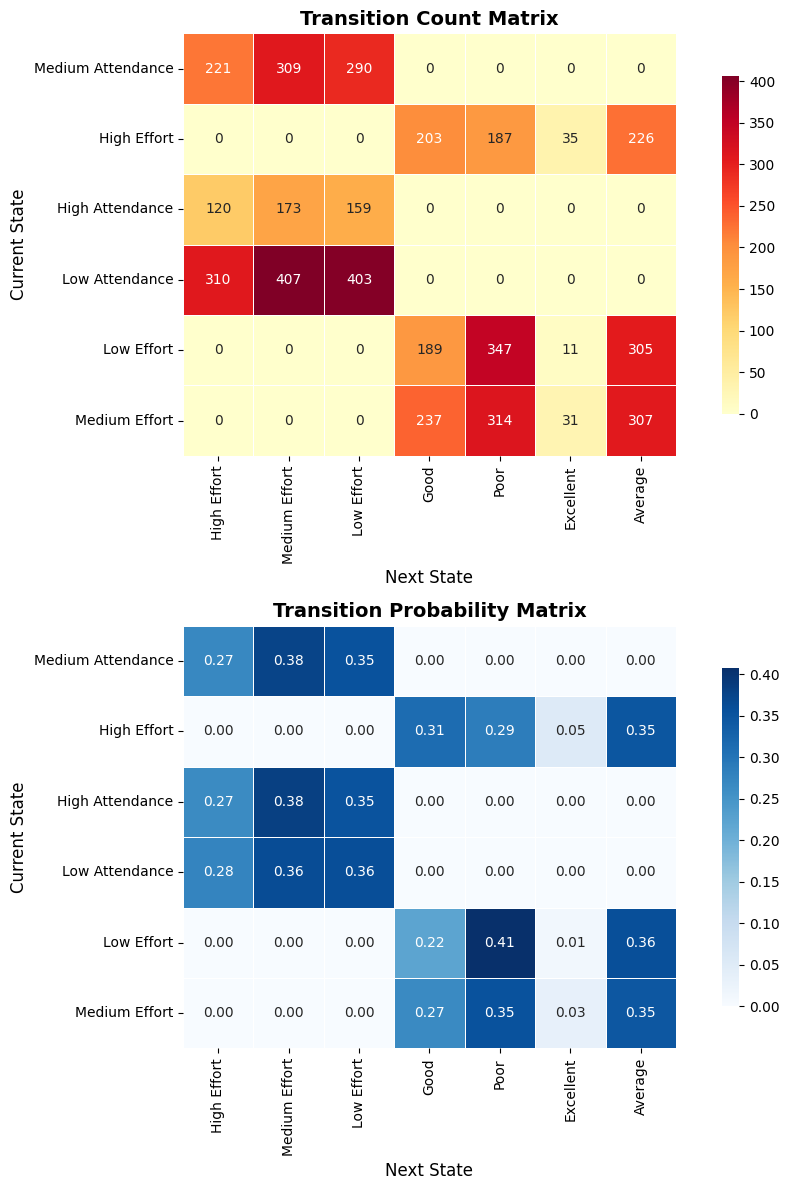

In [ ]:
transition_counts = {}

for seq in df["Sequence"]:
    for i in range(len(seq)-1):

        current_state = seq[i]
        next_state = seq[i+1]

        if current_state not in transition_counts:
            transition_counts[current_state] = {}

        if next_state not in transition_counts[current_state]:
            transition_counts[current_state][next_state] = 0

        transition_counts[current_state][next_state] += 1


count_matrix = pd.DataFrame(transition_counts).T.fillna(0)

print("\nTASK 3 RESULTS")
print("-" * 50)

print("\nTransition Count Matrix:")
display(count_matrix)

prob_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0)

print("\nTransition Probability Matrix:")
display(prob_matrix.round(3))

print("\nRow Sums (must = 1):")
display(prob_matrix.sum(axis=1).round(3))

plt.figure(figsize=(10, 12))

plt.subplot(2, 1, 1)
sns.heatmap(
    count_matrix,
    annot=True,
    cmap="YlOrRd",
    fmt=".0f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Transition Count Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Next State", fontsize=12)
plt.ylabel("Current State", fontsize=12)

plt.subplot(2, 1, 2)
sns.heatmap(
    prob_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Transition Probability Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Next State", fontsize=12)
plt.ylabel("Current State", fontsize=12)

plt.tight_layout()
plt.show()

Task 4

TASK 4 RESULTS
--------------------------------------------------
Starting State: Medium Attendance

Simulated Student Path:
Step 0: Medium Attendance
Step 1: High Effort
Step 2: Good
Step 3: Good
Step 4: Good
Step 5: Good
Step 6: Good
Step 7: Good
Step 8: Good
Step 9: Good
Step 10: Good


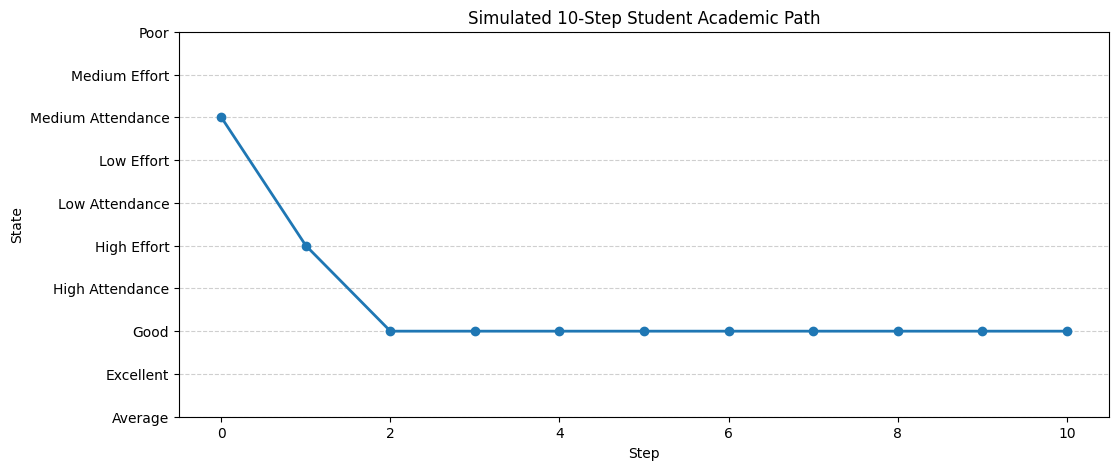

In [ ]:

states = sorted(set(prob_matrix.index).union(set(prob_matrix.columns)))

P_full = pd.DataFrame(
    0.0,
    index=states,
    columns=states
)

P_full.loc[prob_matrix.index, prob_matrix.columns] = prob_matrix


final_states = ["Poor", "Average", "Good", "Excellent"]

for state in final_states:
    if state in P_full.index:
        P_full.loc[state, :] = 0
        P_full.loc[state, state] = 1


for state in P_full.index:
    if P_full.loc[state].sum() == 0:
        P_full.loc[state, state] = 1



def generate_path(transition_matrix, start_state, n_steps=10):
    current = start_state
    path = [current]

    for step in range(n_steps):
        probs = transition_matrix.loc[current].values
        probs = probs / probs.sum()

        next_state = np.random.choice(
            transition_matrix.columns,
            p=probs
        )

        path.append(next_state)
        current = next_state

    return path



start_state = "Medium Attendance"
path = generate_path(P_full, start_state, n_steps=10)

print("TASK 4 RESULTS")
print("-" * 50)
print(f"Starting State: {start_state}")
print("\nSimulated Student Path:")

for step, state in enumerate(path):
    print(f"Step {step}: {state}")



state_positions = {state: i for i, state in enumerate(P_full.columns)}
y = [state_positions[state] for state in path]

plt.figure(figsize=(12, 5))
plt.plot(range(len(path)), y, marker="o", linewidth=2)
plt.yticks(range(len(P_full.columns)), P_full.columns)
plt.xlabel("Step")
plt.ylabel("State")
plt.title("Simulated 10-Step Student Academic Path")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Task 5

TASK 5 RESULTS
--------------------------------------------------
Probability Distribution After 10 Steps:


,0
Average,0.3503
Excellent,0.0322
Good,0.2629
High Attendance,0.0000
High Effort,0.0000
Low Attendance,0.0000
Low Effort,0.0000
Medium Attendance,0.0000
Medium Effort,0.0000
Poor,0.3546


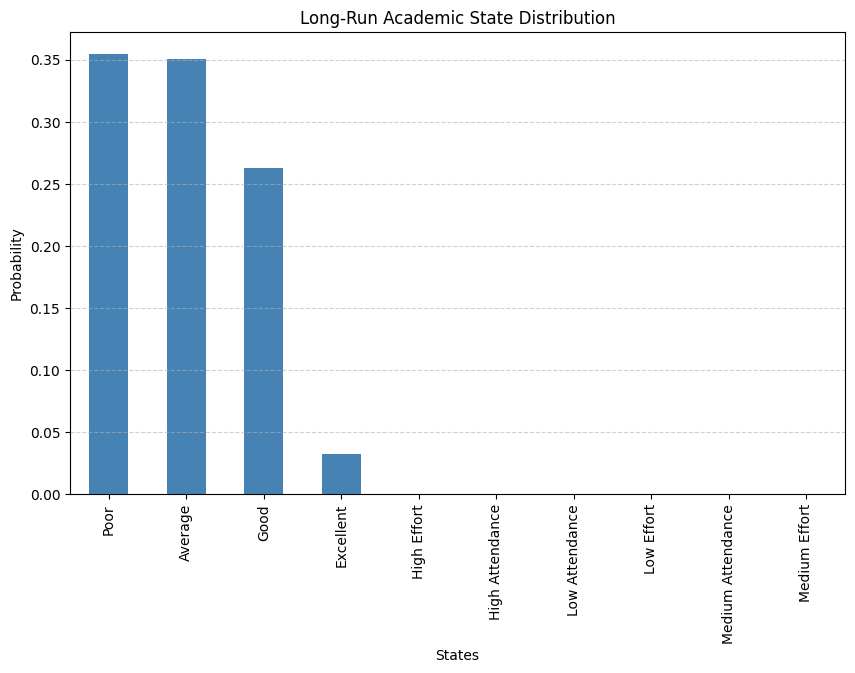

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start_vector = np.array([0, 0, 0, 0.34, 0, 0.33, 0, 0.33, 0, 0])


distribution = start_vector.copy()


for step in range(10):
    distribution = distribution @ P_full.values


final_probs = pd.Series(
    distribution,
    index=P_full.columns
)

print("TASK 5 RESULTS")
print("-" * 50)
print("Probability Distribution After 10 Steps:")
display(final_probs.round(4))

plt.figure(figsize=(10,6))
final_probs.sort_values(ascending=False).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Long-Run Academic State Distribution")
plt.xlabel("States")
plt.ylabel("Probability")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()